# Parte 5 — Bonus: LoRA sobre BERTweet
### Workshop: Clasificación de Emociones en Twitter

BERTweet tiene ~110M parámetros — el doble que DistilBERT. LoRA permite adaptarlo con una fracción mínima de los parámetros.

BERTweet usa la arquitectura de BERT, cuyas proyecciones de atención tienen nombres distintos a DistilBERT:

| Modelo | Proyecciones |
|---|---|
| DistilBERT | `q_lin`, `k_lin`, `v_lin`, `out_lin` |
| BERTweet / BERT | `query`, `key`, `value`, `dense` |

**Prerequisito:** haber ejecutado `part-1-data.ipynb` y `part-2-pipeline.ipynb`

In [1]:
 !pip install peft -q
%run part2_pipeline.ipynb

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
Using the latest cached version of the dataset since tweet_eval couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'emotion' at /teamspace/studios/this_studio/.cache/huggingface/datasets/tweet_eval/emotion/0.0.0/b3a375baf0f409c77e6bc7aa35102b7b3534f8be (last modified on Wed May 27 00:49:02 2026).


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 374
    })
})
compute_metrics OK
make_tokenized_dataset OK
full_evaluation OK
plot_training_curves OK
make_trainer OK

Pipeline lista. Puedes continuar con part-3-distilbert.ipynb


In [3]:
from peft import LoraConfig, get_peft_model, TaskType

MODEL_CHECKPOINT = "vinai/bertweet-base"
HF_REPO          = "Obeney/tweeteval-emotion-bertweet-lora"  # <-- cambia esto
LR_LORA          = 2e-4   # más alto que full FT — pocos parámetros entrenables
     

## Dataset tokenizado

Reutilizamos el tokenizador de BERTweet del experimento anterior.

In [4]:
from transformers import AutoTokenizer

tok_bertweet = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, normalization=True)
ds_bertweet  = make_tokenized_dataset(tok_bertweet)
print(ds_bertweet)

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 374
    })
})


## Inspección de módulos

Antes de aplicar LoRA, inspeccionamos los nombres de las capas lineales de BERTweet.

In [5]:
from transformers import AutoModelForSequenceClassification

base_bt = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT, num_labels=NUM_LABELS,
    id2label=ID2LABEL, label2id=LABEL2ID)

print("Módulos lineales de BERTweet:")
for name, module in base_bt.named_modules():
    if isinstance(module, torch.nn.Linear):
        print(f"  {name}  [{module.in_features} → {module.out_features}]")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Módulos lineales de BERTweet:
  roberta.encoder.layer.0.attention.self.query  [768 → 768]
  roberta.encoder.layer.0.attention.self.key  [768 → 768]
  roberta.encoder.layer.0.attention.self.value  [768 → 768]
  roberta.encoder.layer.0.attention.output.dense  [768 → 768]
  roberta.encoder.layer.0.intermediate.dense  [768 → 3072]
  roberta.encoder.layer.0.output.dense  [3072 → 768]
  roberta.encoder.layer.1.attention.self.query  [768 → 768]
  roberta.encoder.layer.1.attention.self.key  [768 → 768]
  roberta.encoder.layer.1.attention.self.value  [768 → 768]
  roberta.encoder.layer.1.attention.output.dense  [768 → 768]
  roberta.encoder.layer.1.intermediate.dense  [768 → 3072]
  roberta.encoder.layer.1.output.dense  [3072 → 768]
  roberta.encoder.layer.2.attention.self.query  [768 → 768]
  roberta.encoder.layer.2.attention.self.key  [768 → 768]
  roberta.encoder.layer.2.attention.self.value  [768 → 768]
  roberta.encoder.layer.2.attention.output.dense  [768 → 768]
  roberta.encoder.layer.2.

### 📝 TODO 5.1 — Configurar y aplicar LoRA a BERTweet

In [6]:
lora_config = LoraConfig(
    task_type       = TaskType.SEQ_CLS,
    r               = 8,
    lora_alpha      = 16,
    lora_dropout    = 0.1,
    target_modules  = ["query", "value"],  # proyecciones de atención de BERTweet/BERT
    modules_to_save = ["classifier"],       # cabeza clasificadora
)

model_bertweet_lora = get_peft_model(base_bt, lora_config)
model_bertweet_lora.print_trainable_parameters()
# Esperado: ~1-2% de parámetros entrenables

trainable params: 888,580 || all params: 135,791,624 || trainable%: 0.6544


### 📝 TODO 5.2 — Entrenar BERTweet-LoRA

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.971907,0.884554,0.536547,0.692513
2,0.578046,0.615828,0.687923,0.756684
3,0.507817,0.537165,0.728785,0.796791
4,0.488718,0.526272,0.721682,0.788770
5,0.453292,0.530652,0.726572,0.788770


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


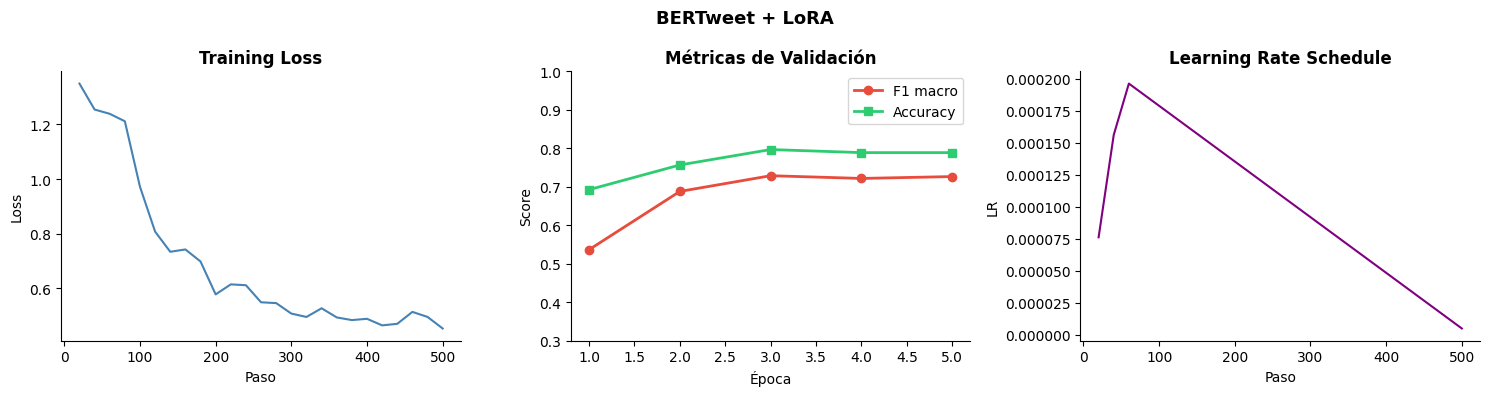

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



  Test — BERTweet-LoRA
              precision    recall  f1-score   support

       anger     0.8423    0.8996    0.8700       558
         joy     0.8421    0.8492    0.8456       358
    optimism     0.8193    0.5528    0.6602       123
     sadness     0.7927    0.7906    0.7916       382

    accuracy                         0.8276      1421
   macro avg     0.8241    0.7731    0.7919      1421
weighted avg     0.8269    0.8276    0.8246      1421



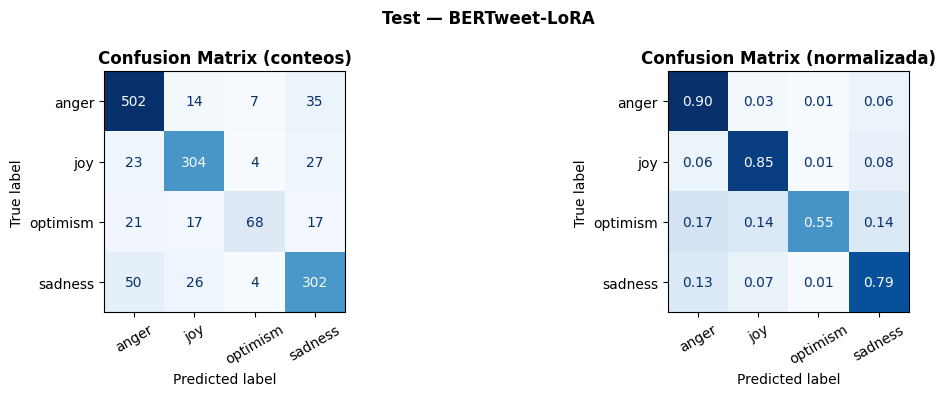

In [7]:
trainer_lora = make_trainer(
    model        = model_bertweet_lora,
    tokenizer    = tok_bertweet,
    tokenized_ds = ds_bertweet,
    output_dir   = "./checkpoints/bertweet-lora",
    lr           = LR_LORA,  # 2e-4 — más alto porque solo entrenan los adaptadores
)

trainer_lora.train()
plot_training_curves(trainer_lora, title="BERTweet + LoRA")
metrics_bertweet_lora = full_evaluation(
    trainer_lora,
    ds_bertweet["test"],
    model_name="BERTweet-LoRA"
)

## Push to Hub

Para subir el modelo LoRA al Hub necesitamos fusionarlo primero (`merge_and_unload`), que aplica $W' = W + BA$ y devuelve un modelo estándar sin overhead PEFT.

In [8]:
merged = model_bertweet_lora.merge_and_unload()
merged.push_to_hub(HF_REPO, commit_message="BERTweet LoRA r=8 — merged")
tok_bertweet.push_to_hub(HF_REPO)
print(f"Modelo publicado en: https://huggingface.co/{HF_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Modelo publicado en: https://huggingface.co/Obeney/tweeteval-emotion-bertweet-lora
